# HW3-4: Rainbow DQN for Random Mode GridWorld

組合技術：
- ✅ Double DQN
- ✅ Dueling DQN
- ✅ Prioritized Experience Replay (PER)
- ✅ Multi-step Returns (n-step=3)
- ✅ Noisy Nets

## Step 1：安裝 & 下載環境

In [1]:
!pip install lightning -q
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/Gridworld.py
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/GridBoard.py
print('安裝完成！')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 21.3 MB/s eta 0:00:00
安裝完成！


## Step 2：Import

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
import copy
import random
import math
from collections import deque
from torch.utils.data import DataLoader, IterableDataset
from matplotlib import pylab as plt
from Gridworld import Gridworld

action_set = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}
print('Import 完成！')

Import 完成！


## Step 3：Noisy Nets
把 nn.Linear 換成帶有可學習噪聲的 NoisyLinear，取代 ε-greedy 探索

In [3]:
class NoisyLinear(nn.Module):
    """
    Noisy Linear Layer
    weight = μ_w + σ_w × ε_w
    bias   = μ_b + σ_b × ε_b
    μ、σ 都是可學習參數，ε 是每次 forward 時重新採樣的噪聲
    """
    def __init__(self, in_features, out_features, sigma_init=0.5):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # 可學習參數：均值 μ
        self.mu_w    = nn.Parameter(torch.empty(out_features, in_features))
        self.mu_b    = nn.Parameter(torch.empty(out_features))
        # 可學習參數：標準差 σ
        self.sigma_w = nn.Parameter(torch.empty(out_features, in_features))
        self.sigma_b = nn.Parameter(torch.empty(out_features))

        # 噪聲（不是參數，每次 forward 重新採樣）
        self.register_buffer('eps_w', torch.empty(out_features, in_features))
        self.register_buffer('eps_b', torch.empty(out_features))

        self.sigma_init = sigma_init
        self._init_params()
        self.sample_noise()

    def _init_params(self):
        bound = 1.0 / math.sqrt(self.in_features)
        nn.init.uniform_(self.mu_w, -bound, bound)
        nn.init.uniform_(self.mu_b, -bound, bound)
        nn.init.constant_(self.sigma_w, self.sigma_init / math.sqrt(self.in_features))
        nn.init.constant_(self.sigma_b, self.sigma_init / math.sqrt(self.out_features))

    def _f(self, x):
        """Factorised noise function"""
        return x.sign() * x.abs().sqrt()

    def sample_noise(self):
        """重新採樣噪聲（每個 training step 呼叫一次）"""
        eps_in  = self._f(torch.randn(self.in_features))
        eps_out = self._f(torch.randn(self.out_features))
        self.eps_w.copy_(eps_out.outer(eps_in))
        self.eps_b.copy_(eps_out)

    def forward(self, x):
        if self.training:
            w = self.mu_w + self.sigma_w * self.eps_w
            b = self.mu_b + self.sigma_b * self.eps_b
        else:
            w = self.mu_w
            b = self.mu_b
        return F.linear(x, w, b)

print('NoisyLinear 定義完成！')

NoisyLinear 定義完成！


## Step 4：Rainbow 網路架構
Dueling 架構 + NoisyLinear（取代所有 nn.Linear）

In [4]:
class RainbowDQN(nn.Module):
    """
    Rainbow 網路：Dueling 架構 + Noisy Nets
    所有 Linear 層換成 NoisyLinear
    """
    def __init__(self, input_dim=64, hidden1=150, hidden2=100, n_actions=4):
        super().__init__()
        # Backbone（特徵提取）
        self.fc1 = NoisyLinear(input_dim, hidden1)
        self.fc2 = NoisyLinear(hidden1, hidden2)
        # Value stream
        self.value_stream = NoisyLinear(hidden2, 1)
        # Advantage stream
        self.adv_stream   = NoisyLinear(hidden2, n_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        V = self.value_stream(x)
        A = self.adv_stream(x)
        return V + (A - A.mean(dim=1, keepdim=True))

    def sample_noise(self):
        """對所有 NoisyLinear 層重新採樣噪聲"""
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.sample_noise()

print('RainbowDQN 定義完成！')

RainbowDQN 定義完成！


## Step 5：PER + n-step Buffer
兩個功能合併在同一個 Buffer 裡

In [5]:
class SumTree:
    """
    SumTree 資料結構：支援 O(log n) 的優先級採樣
    葉節點儲存優先級，父節點儲存子節點的總和
    """
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree     = np.zeros(2 * capacity - 1)  # 完整二元樹
        self.data     = np.zeros(capacity, dtype=object)
        self.ptr      = 0   # 當前寫入位置
        self.size     = 0   # 當前資料數量

    def _propagate(self, idx, delta):
        parent = (idx - 1) // 2
        self.tree[parent] += delta
        if parent != 0:
            self._propagate(parent, delta)

    def update(self, idx, priority):
        delta = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, delta)

    def add(self, priority, data):
        idx = self.ptr + self.capacity - 1
        self.data[self.ptr] = data
        self.update(idx, priority)
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def get(self, s):
        idx = 0
        while True:
            left  = 2 * idx + 1
            right = left + 1
            if left >= len(self.tree):
                break
            idx = left if s <= self.tree[left] else right
            if right < len(self.tree) and s > self.tree[left]:
                s -= self.tree[left]
        data_idx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[data_idx]

    @property
    def total(self):
        return self.tree[0]


class PERNStepBuffer:
    """
    PER + n-step Returns 合併 Buffer
    - n-step：累積 n 步獎勵後才存入 PER buffer
    - PER：按 TD error 決定採樣機率
    """
    def __init__(self, capacity=1000, n_step=3, gamma=0.9, alpha=0.6):
        self.tree     = SumTree(capacity)
        self.capacity = capacity
        self.n_step   = n_step
        self.gamma    = gamma
        self.alpha    = alpha          # 優先級指數，0=均勻，1=完全優先
        self.max_priority = 1.0        # 新經驗的初始優先級
        self.n_step_buffer = deque(maxlen=n_step)  # 暫存 n 步經驗

    def _get_n_step_info(self):
        """計算 n-step 累積獎勵和最終狀態"""
        reward = 0
        for i, (s, a, r, s2, d) in enumerate(self.n_step_buffer):
            reward += (self.gamma ** i) * r
            if d:
                break
        state      = self.n_step_buffer[0][0]   # 第一步的狀態
        action     = self.n_step_buffer[0][1]   # 第一步的動作
        next_state = self.n_step_buffer[-1][3]  # 最後一步的下一狀態
        done       = self.n_step_buffer[-1][4]  # 最後一步的 done
        return state, action, reward, next_state, done

    def push(self, state, action, reward, next_state, done):
        """存入一步經驗，累積夠 n 步後存入 PER buffer"""
        self.n_step_buffer.append((state, action, reward, next_state, done))
        if len(self.n_step_buffer) == self.n_step:
            exp = self._get_n_step_info()
            self.tree.add(self.max_priority ** self.alpha, exp)

    def sample(self, batch_size, beta=0.4):
        """
        按優先級採樣，回傳 (batch, weights, indices)
        weights：importance sampling weights，修正採樣偏差
        """
        indices    = []
        priorities = []
        batch      = []
        segment    = self.tree.total / batch_size

        for i in range(batch_size):
            s = random.uniform(segment * i, segment * (i + 1))
            idx, priority, data = self.tree.get(s)
            if data == 0:  # 空節點，跳過
                continue
            indices.append(idx)
            priorities.append(priority)
            batch.append(data)

        # 計算 importance sampling weights
        probs   = np.array(priorities) / self.tree.total
        weights = (self.tree.size * probs) ** (-beta)
        weights = weights / weights.max()  # 正規化
        return batch, weights, indices

    def update_priorities(self, indices, td_errors):
        """訓練後更新優先級"""
        for idx, td_error in zip(indices, td_errors):
            priority = (abs(td_error) + 1e-6) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return self.tree.size


class PERDataset(IterableDataset):
    def __init__(self, buffer, batch_size, beta):
        self.buffer     = buffer
        self.batch_size = batch_size
        self.beta       = beta

    def __iter__(self):
        batch, weights, indices = self.buffer.sample(self.batch_size, self.beta)
        states, actions, rewards, next_states, dones = zip(*batch)
        yield (
            torch.cat(list(states)),
            torch.tensor(list(actions),  dtype=torch.long),
            torch.tensor(list(rewards),  dtype=torch.float),
            torch.cat(list(next_states)),
            torch.tensor(list(dones),    dtype=torch.float),
            torch.tensor(weights,        dtype=torch.float),
            indices
        )

print('PER + n-step Buffer 定義完成！')

PER + n-step Buffer 定義完成！


## Step 6：Rainbow Lightning Module

In [12]:
class RainbowLightning(L.LightningModule):
    def __init__(
        self,
        lr=1e-3,
        gamma=0.9,
        batch_size=200,
        sync_freq=500,
        n_step=3,
        alpha=0.6,
        beta_start=0.4,
        beta_end=1.0,
        mode='random'
    ):
        super().__init__()
        self.save_hyperparameters()

        self.net    = RainbowDQN()
        self.target = RainbowDQN()
        self.target.load_state_dict(self.net.state_dict())
        self.target.eval()

        self.buffer     = PERNStepBuffer(
            capacity=1000, n_step=n_step, gamma=gamma, alpha=alpha
        )
        self.loss_fn    = nn.MSELoss(reduction='none')
        self.losses     = []
        self.step_count = 0
        self.beta       = beta_start

    def _get_state(self, game):
        s = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        return torch.from_numpy(s).float()

    def _select_action(self, state):
        with torch.no_grad():
            return self.net(state).argmax().item()

    def _run_episode(self):
        game  = Gridworld(size=4, mode=self.hparams.mode)
        state = self._get_state(game)
        mov   = 0
        while True:
            mov += 1
            self.net.sample_noise()
            action_ = self._select_action(state)
            game.makeMove(action_set[action_])
            next_state = self._get_state(game)
            reward     = game.reward()
            done       = reward != -1
            self.buffer.push(state, action_, reward, next_state, done)
            state = next_state
            if done or mov >= 50:
                break

    def training_step(self, batch, batch_idx):
        self._run_episode()
        self.step_count += 1

        if len(self.buffer) < self.hparams.batch_size:
            return torch.tensor(0.0, requires_grad=True)

        states      = batch[0].squeeze(0).float()
        actions     = batch[1].squeeze(0).long()
        rewards     = batch[2].squeeze(0).float()
        next_states = batch[3].squeeze(0).float()
        dones       = batch[4].squeeze(0).float()
        weights     = batch[5].squeeze(0).float()
        indices     = batch[6]

        self.net.sample_noise()
        self.target.sample_noise()

        Q1 = self.net(states)
        with torch.no_grad():
            best_actions = self.net(next_states).argmax(dim=1)
            Q2 = self.target(next_states).gather(
                1, best_actions.unsqueeze(1)
            ).squeeze(1)

        gamma_n = self.hparams.gamma ** self.hparams.n_step
        Y = rewards + gamma_n * ((1 - dones) * Q2)
        X = Q1.gather(1, actions.unsqueeze(1)).squeeze(1)

        td_errors    = (X - Y.detach()).abs().detach().cpu().numpy()
        element_loss = self.loss_fn(X, Y.detach())
        loss         = (weights * element_loss).mean()

        if isinstance(indices[0], list):
            indices = indices[0]
        self.buffer.update_priorities(indices, td_errors)

        if self.step_count % self.hparams.sync_freq == 0:
            self.target.load_state_dict(self.net.state_dict())

        self.beta = min(
            self.hparams.beta_end,
            self.beta + (self.hparams.beta_end - self.hparams.beta_start) / 5000
        )

        self.log('train_loss', loss, prog_bar=True)
        self.log('beta', self.beta, prog_bar=True)
        self.losses.append(loss.item())
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.net.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=500, gamma=0.9
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'interval': 'step'}
        }

    def train_dataloader(self):
        while len(self.buffer) < self.hparams.batch_size:
            self._run_episode()
        dataset = PERDataset(self.buffer, self.hparams.batch_size, self.beta)
        return DataLoader(dataset, batch_size=self.hparams.batch_size)

print('RainbowLightning 定義完成！')

RainbowLightning 定義完成！


## Step 7：訓練

In [16]:
rainbow = RainbowLightning(
    lr=1e-3,
    gamma=0.9,
    batch_size=200,
    sync_freq=500,
    n_step=3,
    alpha=0.6,
    beta_start=0.4,
    beta_end=1.0,
    mode='random'
)

trainer = L.Trainer(
    max_epochs=5000,
    gradient_clip_val=1.0,
    enable_checkpointing=False,
    enable_model_summary=False,
    logger=False,
)

print('開始訓練...')
trainer.fit(rainbow)
print('訓練完成！')

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

開始訓練...


INFO: `Trainer.fit` stopped: `max_epochs=5000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5000` reached.


訓練完成！


## Step 8：評估結果

In [26]:
def test_model(model, mode='random', n_games=500):
    wins = 0
    model.eval()
    for _ in range(n_games):
        game   = Gridworld(size=4, mode=mode)
        state_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state  = torch.from_numpy(state_).float()
        status = 1
        i = 0
        while status == 1:
            with torch.no_grad():
                action_ = model(state).argmax().item()
            game.makeMove(action_set[action_])
            state_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
            state  = torch.from_numpy(state_).float()
            reward = game.reward()
            if reward == 10:
                wins += 1
                status = 0
            elif reward == -10:
                status = 0
            i += 1
            if i > 15:
                status = 0
    win_rate = wins / n_games * 100
    print(f'Games: {n_games} | Wins: {wins} | Win Rate: {win_rate:.1f}%')
    return win_rate

print('=== Rainbow DQN 評估結果 ===')
win_rate = test_model(rainbow.net, mode='random', n_games=500)

=== Rainbow DQN 評估結果 ===
Games: 500 | Wins: 441 | Win Rate: 88.2%


## Step 9：Loss 曲線

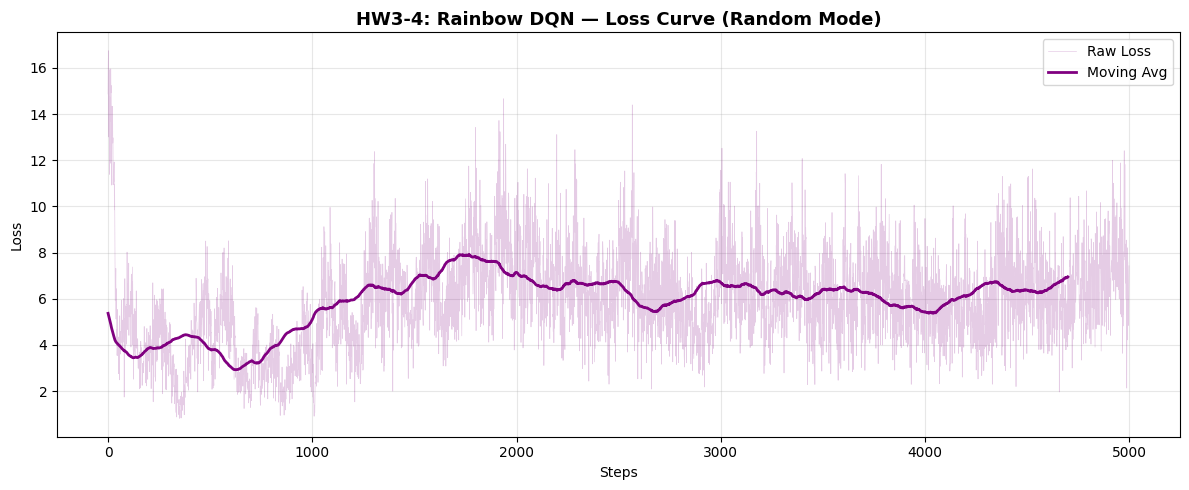

總訓練步數：5000
最終 β 值：1.0000
最終勝率：88.2%
HW3-3 勝率：86.0%
Rainbow 提升：+2.2%


In [27]:
losses = np.array(rainbow.losses)

def moving_avg(data, window=300):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(losses, alpha=0.2, color='purple', linewidth=0.5, label='Raw Loss')
if len(losses) > 300:
    plt.plot(moving_avg(losses), color='purple', linewidth=2, label='Moving Avg')
plt.title('HW3-4: Rainbow DQN — Loss Curve (Random Mode)', fontsize=13, fontweight='bold')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rainbow_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'總訓練步數：{rainbow.step_count}')
print(f'最終 β 值：{rainbow.beta:.4f}')
print(f'最終勝率：{win_rate:.1f}%')
print(f'HW3-3 勝率：86.0%')
print(f'Rainbow 提升：{win_rate - 86.0:+.1f}%')